<a href="https://colab.research.google.com/github/derekwilsonyt/HandsOnDeepLearning/blob/main/HODL_Railway_Defect_Models_Consolodated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Railway Track Defect Detection: CNN vs Vision Transformer Comparison

**Course**: Hands-on Deep Learning — Final Project

**Task**: Binary classification of railway track images (Defective vs Non-Defective)

**Dataset**: [Railway Track Fault Detection](https://www.kaggle.com/datasets/salmaneunus/railway-track-fault-detection) (Kaggle)

**Models Compared**:
1. **EfficientNet-B0** (CNN baseline)
2. **ViT-Base** (patch16, 224×224)
3. **ViT-Large** (patch16, 224×224)
4. **ViT-Huge** (patch14, 224×224) — with staged fine-tuning

**Comparison Method**: ViTs vs CNNs for binary railway defect image classification task


In [7]:
!pip install -q torch torchvision timm scikit-learn matplotlib

In [8]:
import os
import json
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import timm

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score)

# ── Reproducibility ──
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


In [9]:
#Download data from Kaggle

from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)
kaggle_credentials = {
    "username": userdata.get('KAGGLE_USERNAME'),
    "key": userdata.get('KAGGLE_KEY')
}
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install kaggle -q
!kaggle datasets download -d salmaneunus/railway-track-fault-detection -q

with zipfile.ZipFile('railway-track-fault-detection.zip', 'r') as zip_ref:
    zip_ref.extractall('data/')

print("Download and extraction complete.")


Dataset URL: https://www.kaggle.com/datasets/salmaneunus/railway-track-fault-detection
License(s): copyright-authors
Download and extraction complete.


In [10]:
# Verify dataset structure
base_path = 'data/Railway Track fault Detection Updated'

for root, dirs, files in os.walk('data/'):
    level = root.replace('data/', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')


/
Railway Track fault Detection Updated/
  Train/
    Defective/
    Non defective/
  Validation/
    Defective/
    Non defective/
  Test/
    Defective/
    Non defective/


In [11]:
#Transforms & DataLoaders

# We use the same augmentation and normalization for all models to ensure a fair comparison.
# Training: RandomHorizontalFlip, RandomVerticalFlip, RandomRotation(15), ColorJitter
# Validation/Test: Resize only
# Normalization: ImageNet statistics [0.485, 0.456, 0.406]

# Shared data transformation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = datasets.ImageFolder(f'{base_path}/Train', transform=train_transform)
val_dataset   = datasets.ImageFolder(f'{base_path}/Validation', transform=val_test_transform)
test_dataset  = datasets.ImageFolder(f'{base_path}/Test', transform=val_test_transform)

num_classes = len(train_dataset.classes)
print(f"Classes:    {train_dataset.classes}")
print(f"Num classes: {num_classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Classes:    ['Defective', 'Non defective']
Num classes: 2
Train: 300 | Val: 62 | Test: 22


In [12]:
# DataLoaders
# We use batch_size=16 as the default for most models.
# ViT-Huge will use batch_size=4 with gradient accumulation due to memory.

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f"Loaders ready (batch_size={BATCH_SIZE})")


Loaders ready (batch_size=16)


In [13]:
# Standard training loop (CNN, ViT-Base, ViT-Large)
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


# AMP training loop with gradient accumulation (ViT-Huge)
def train_epoch_amp(model, loader, optimizer, criterion, scaler, accum_steps=4):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad(set_to_none=True)

    for step, (images, labels) in enumerate(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * accum_steps
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total


# Evaluation (shared)
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total


# Full training driver
def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion,
                num_epochs, save_path, use_amp=False, scaler=None, accum_steps=1):
    """Train a model and return history dict."""
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        if use_amp:
            train_loss, train_acc = train_epoch_amp(
                model, train_loader, optimizer, criterion, scaler, accum_steps)
        else:
            train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)

        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

        print(f"  Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
              f"{' ✅' if val_acc >= best_val_acc else ''}")

    print(f"  Best Val Accuracy: {best_val_acc:.4f}\n")
    return history, best_val_acc


# Test evaluation
def test_model(model, loader, class_names, title="Model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.to(device))
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec  = recall_score(all_labels, all_preds, average='weighted')
    f1   = f1_score(all_labels, all_preds, average='weighted')

    print(f"{'='*55}")
    print(f"  {title} — TEST RESULTS")
    print(f"{'='*55}")
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, digits=4))
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"{'='*55}\n")

    return all_labels, all_preds, {'accuracy': acc, 'precision': prec,
                                    'recall': rec, 'f1': f1}


**Model 1: EfficientNet-B0 (CNN Baseline)**

EfficientNet-B0 is a compact CNN that uses compound scaling. We use ImageNet-pretrained weights
and replace the final classifier head for binary classification. All layers are fine-tuned.


In [14]:
set_seed(42)

model_cnn = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model_cnn.classifier[1] = nn.Linear(model_cnn.classifier[1].in_features, num_classes)
model_cnn = model_cnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_cnn = torch.optim.lr_scheduler.StepLR(optimizer_cnn, step_size=5, gamma=0.5)

print(f"EfficientNet-B0 — params: {sum(p.numel() for p in model_cnn.parameters()):,}")
print(f"Classifier head: {model_cnn.classifier}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 53.3MB/s]


EfficientNet-B0 — params: 4,010,110
Classifier head: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [15]:
print("Training EfficientNet-B0...")
history_cnn, best_cnn = train_model(
    model_cnn, train_loader, val_loader, optimizer_cnn, scheduler_cnn,
    criterion, num_epochs=20, save_path='best_cnn.pth'
)


Training EfficientNet-B0...
  Epoch [1/20] Train Loss: 0.6287 Acc: 0.6767 | Val Loss: 0.4893 Acc: 0.7742 ✅
  Epoch [2/20] Train Loss: 0.5281 Acc: 0.7633 | Val Loss: 0.4566 Acc: 0.8065 ✅
  Epoch [3/20] Train Loss: 0.4268 Acc: 0.8200 | Val Loss: 0.4158 Acc: 0.8065 ✅
  Epoch [4/20] Train Loss: 0.3897 Acc: 0.8333 | Val Loss: 0.3858 Acc: 0.8065 ✅
  Epoch [5/20] Train Loss: 0.2992 Acc: 0.8700 | Val Loss: 0.3446 Acc: 0.8226 ✅
  Epoch [6/20] Train Loss: 0.2489 Acc: 0.9267 | Val Loss: 0.3382 Acc: 0.8548 ✅
  Epoch [7/20] Train Loss: 0.2449 Acc: 0.9033 | Val Loss: 0.3287 Acc: 0.8548 ✅
  Epoch [8/20] Train Loss: 0.1912 Acc: 0.9500 | Val Loss: 0.3267 Acc: 0.8548 ✅
  Epoch [9/20] Train Loss: 0.1835 Acc: 0.9500 | Val Loss: 0.3259 Acc: 0.8548 ✅
  Epoch [10/20] Train Loss: 0.1615 Acc: 0.9533 | Val Loss: 0.3288 Acc: 0.8548 ✅
  Epoch [11/20] Train Loss: 0.1265 Acc: 0.9833 | Val Loss: 0.3252 Acc: 0.8710 ✅
  Epoch [12/20] Train Loss: 0.1267 Acc: 0.9533 | Val Loss: 0.3269 Acc: 0.8548
  Epoch [13/20] Train L

In [16]:
model_cnn.load_state_dict(torch.load('best_cnn.pth', map_location=device))
labels_cnn, preds_cnn, metrics_cnn = test_model(
    model_cnn, test_loader, train_dataset.classes, title="EfficientNet-B0"
)


  EfficientNet-B0 — TEST RESULTS
               precision    recall  f1-score   support

    Defective     0.9091    0.9091    0.9091        11
Non defective     0.9091    0.9091    0.9091        11

     accuracy                         0.9091        22
    macro avg     0.9091    0.9091    0.9091        22
 weighted avg     0.9091    0.9091    0.9091        22

  Accuracy:  0.9091
  Precision: 0.9091
  Recall:    0.9091
  F1 Score:  0.9091



**Model 2: ViT-Base (patch16, 224)**

ViT-Base with 86M parameters. We fine-tune all layers with AdamW and cosine annealing.
This is a full fine-tune approach (no frozen backbone).


In [17]:
set_seed(42)

model_vit_base = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=2)
model_vit_base = model_vit_base.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_vb = torch.optim.AdamW(model_vit_base.parameters(), lr=1e-4, weight_decay=0.01)
scheduler_vb = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vb, T_max=10)

print(f"ViT-Base — params: {sum(p.numel() for p in model_vit_base.parameters()):,}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT-Base — params: 85,800,194


In [18]:
print("Training ViT-Base...")
history_vit_base, best_vb = train_model(
    model_vit_base, train_loader, val_loader, optimizer_vb, scheduler_vb,
    criterion, num_epochs=10, save_path='best_vit_base.pth'
)


Training ViT-Base...
  Epoch [1/10] Train Loss: 0.8323 Acc: 0.6100 | Val Loss: 0.7393 Acc: 0.5000 ✅
  Epoch [2/10] Train Loss: 0.7021 Acc: 0.5667 | Val Loss: 0.5851 Acc: 0.6774 ✅
  Epoch [3/10] Train Loss: 0.6473 Acc: 0.6533 | Val Loss: 0.6111 Acc: 0.6290
  Epoch [4/10] Train Loss: 0.5692 Acc: 0.6867 | Val Loss: 0.6397 Acc: 0.6774 ✅
  Epoch [5/10] Train Loss: 0.6525 Acc: 0.6100 | Val Loss: 0.4949 Acc: 0.8226 ✅
  Epoch [6/10] Train Loss: 0.5036 Acc: 0.7533 | Val Loss: 0.5399 Acc: 0.6935
  Epoch [7/10] Train Loss: 0.4887 Acc: 0.7167 | Val Loss: 0.5160 Acc: 0.6935
  Epoch [8/10] Train Loss: 0.4481 Acc: 0.7700 | Val Loss: 0.4152 Acc: 0.8065
  Epoch [9/10] Train Loss: 0.4002 Acc: 0.8200 | Val Loss: 0.4560 Acc: 0.7903
  Epoch [10/10] Train Loss: 0.3881 Acc: 0.8167 | Val Loss: 0.3885 Acc: 0.8710 ✅
  Best Val Accuracy: 0.8710



In [19]:
model_vit_base.load_state_dict(torch.load('best_vit_base.pth', map_location=device))
labels_vb, preds_vb, metrics_vit_base = test_model(
    model_vit_base, test_loader, train_dataset.classes, title="ViT-Base"
)


  ViT-Base — TEST RESULTS
               precision    recall  f1-score   support

    Defective     0.8750    0.6364    0.7368        11
Non defective     0.7143    0.9091    0.8000        11

     accuracy                         0.7727        22
    macro avg     0.7946    0.7727    0.7684        22
 weighted avg     0.7946    0.7727    0.7684        22

  Accuracy:  0.7727
  Precision: 0.7946
  Recall:    0.7727
  F1 Score:  0.7684



**Model 3: ViT-Large (patch16, 224)**

ViT-Large with 304M parameters. Same full fine-tune approach as ViT-Base.



In [33]:
set_seed(42)

model_vit_large = timm.create_model('vit_large_patch16_224', pretrained=True, num_classes=2)
model_vit_large = model_vit_large.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_vl = torch.optim.AdamW(model_vit_large.parameters(), lr=1e-4, weight_decay=0.01)
scheduler_vl = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vl, T_max=10)

print(f"ViT-Large — params: {sum(p.numel() for p in model_vit_large.parameters()):,}")


ViT-Large — params: 303,303,682


In [34]:
print("Training ViT-Large...")
history_vit_large, best_vl = train_model(
    model_vit_large, train_loader, val_loader, optimizer_vl, scheduler_vl,
    criterion, num_epochs=10, save_path='best_vit_large.pth'
)


Training ViT-Large...
  Epoch [1/10] Train Loss: 1.0863 Acc: 0.7000 | Val Loss: 0.5129 Acc: 0.7419 ✅
  Epoch [2/10] Train Loss: 0.4988 Acc: 0.7600 | Val Loss: 0.4179 Acc: 0.7903 ✅
  Epoch [3/10] Train Loss: 0.3101 Acc: 0.8500 | Val Loss: 0.3496 Acc: 0.8871 ✅
  Epoch [4/10] Train Loss: 0.2188 Acc: 0.8900 | Val Loss: 0.3105 Acc: 0.8710
  Epoch [5/10] Train Loss: 0.1618 Acc: 0.9267 | Val Loss: 0.4290 Acc: 0.8871 ✅
  Epoch [6/10] Train Loss: 0.0815 Acc: 0.9700 | Val Loss: 0.3505 Acc: 0.8871 ✅
  Epoch [7/10] Train Loss: 0.0878 Acc: 0.9667 | Val Loss: 0.5402 Acc: 0.8710
  Epoch [8/10] Train Loss: 0.0553 Acc: 0.9800 | Val Loss: 0.3802 Acc: 0.9194 ✅
  Epoch [9/10] Train Loss: 0.0156 Acc: 0.9967 | Val Loss: 0.3760 Acc: 0.9355 ✅
  Epoch [10/10] Train Loss: 0.0331 Acc: 0.9867 | Val Loss: 0.3689 Acc: 0.9355 ✅
  Best Val Accuracy: 0.9355



In [35]:
model_vit_large.load_state_dict(torch.load('best_vit_large.pth', map_location=device))
labels_vl, preds_vl, metrics_vit_large = test_model(
    model_vit_large, test_loader, train_dataset.classes, title="ViT-Large"
)


  ViT-Large — TEST RESULTS
               precision    recall  f1-score   support

    Defective     1.0000    1.0000    1.0000        11
Non defective     1.0000    1.0000    1.0000        11

     accuracy                         1.0000        22
    macro avg     1.0000    1.0000    1.0000        22
 weighted avg     1.0000    1.0000    1.0000        22

  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000



**Model 4: ViT-Huge (patch14, 224) — Staged Fine-Tuning**

ViT-Huge has 632M parameters — too many for fine-tune end-to-end on 300 images.


**two-stage approach**:

1. **Stage 1 (Head-only)**: Freeze backbone, train only the classification head for 3 epochs
2. **Stage 2 (Partial fine-tune)**: Unfreeze the last 2 transformer blocks + head, train with a lower learning rate for 5 epochs

We also use **mixed precision** (AMP) and **gradient accumulation** (effective batch size = 4 × 4 = 16) to fit in GPU memory.


In [23]:
set_seed(42)

# Need smaller batch size for Huge model
train_loader_huge = DataLoader(train_dataset, batch_size=4, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=True)
val_loader_huge   = DataLoader(val_dataset, batch_size=4, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)
test_loader_huge  = DataLoader(test_dataset, batch_size=4, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=True)

model_vit_huge = timm.create_model('vit_huge_patch14_224', pretrained=True, num_classes=2)
model_vit_huge = model_vit_huge.to(device)

print(f"ViT-Huge — params: {sum(p.numel() for p in model_vit_huge.parameters()):,}")


model.safetensors:   0%|          | 0.00/2.52G [00:00<?, ?B/s]

ViT-Huge — params: 630,767,362


In [24]:
# Stage 1: Head-Only Training
# Freeze everything, unfreeze head only

for param in model_vit_huge.parameters():
    param.requires_grad = False
for param in model_vit_huge.head.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model_vit_huge.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_vit_huge.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

criterion = nn.CrossEntropyLoss()
optimizer_vh1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_vit_huge.parameters()),
    lr=1e-4, weight_decay=0.01
)
scheduler_vh1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vh1, T_max=3)
scaler = GradScaler('cuda')


Trainable: 2,562 / 630,767,362 (0.00%)


In [25]:
print("ViT-Huge Stage 1: Head-only training...")
history_huge_s1, best_vh1 = train_model(
    model_vit_huge, train_loader_huge, val_loader_huge,
    optimizer_vh1, scheduler_vh1, criterion,
    num_epochs=3, save_path='best_vit_huge_head.pth',
    use_amp=True, scaler=scaler, accum_steps=4
)


ViT-Huge Stage 1: Head-only training...
  Epoch [1/3] Train Loss: 0.6942 Acc: 0.5100 | Val Loss: 0.6811 Acc: 0.6613 ✅
  Epoch [2/3] Train Loss: 0.6858 Acc: 0.5733 | Val Loss: 0.6766 Acc: 0.6935 ✅
  Epoch [3/3] Train Loss: 0.6831 Acc: 0.5767 | Val Loss: 0.6748 Acc: 0.7903 ✅
  Best Val Accuracy: 0.7903



In [26]:
# Stage 2: Partial Fine-Tuning (last 2 blocks + head)
# Unfreeze last 2 transformer blocks

for param in model_vit_huge.head.parameters():
    param.requires_grad = True
if hasattr(model_vit_huge, 'blocks'):
    for block in model_vit_huge.blocks[-2:]:
        for param in block.parameters():
            param.requires_grad = True

trainable = sum(p.numel() for p in model_vit_huge.parameters() if p.requires_grad)
print(f"Trainable after unfreezing: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

optimizer_vh2 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_vit_huge.parameters()),
    lr=2e-5, weight_decay=0.01
)
scheduler_vh2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_vh2, T_max=5)


Trainable after unfreezing: 39,357,442 / 630,767,362 (6.24%)


In [27]:
print("ViT-Huge Stage 2: Partial fine-tuning...")
history_huge_s2, best_vh2 = train_model(
    model_vit_huge, train_loader_huge, val_loader_huge,
    optimizer_vh2, scheduler_vh2, criterion,
    num_epochs=5, save_path='best_vit_huge_ft.pth',
    use_amp=True, scaler=scaler, accum_steps=4
)

# Combine histories for plotting
history_vit_huge = {k: history_huge_s1[k] + history_huge_s2[k]
                    for k in history_huge_s1}


ViT-Huge Stage 2: Partial fine-tuning...
  Epoch [1/5] Train Loss: 0.6762 Acc: 0.6433 | Val Loss: 0.6654 Acc: 0.8226 ✅
  Epoch [2/5] Train Loss: 0.6646 Acc: 0.6933 | Val Loss: 0.6571 Acc: 0.8226 ✅
  Epoch [3/5] Train Loss: 0.6565 Acc: 0.7033 | Val Loss: 0.6504 Acc: 0.8387 ✅
  Epoch [4/5] Train Loss: 0.6473 Acc: 0.7367 | Val Loss: 0.6475 Acc: 0.8548 ✅
  Epoch [5/5] Train Loss: 0.6475 Acc: 0.7233 | Val Loss: 0.6466 Acc: 0.8548 ✅
  Best Val Accuracy: 0.8548



In [28]:
# Load best model (prefer fine-tuned, fallback to head-only)
best_vh = max(best_vh1, best_vh2)
load_path = 'best_vit_huge_ft.pth' if best_vh2 >= best_vh1 else 'best_vit_huge_head.pth'
model_vit_huge.load_state_dict(torch.load(load_path, map_location=device))
print(f"Loaded best ViT-Huge from: {load_path} (val acc: {best_vh:.4f})")

labels_vh, preds_vh, metrics_vit_huge = test_model(
    model_vit_huge, test_loader_huge, train_dataset.classes, title="ViT-Huge"
)


Loaded best ViT-Huge from: best_vit_huge_ft.pth (val acc: 0.8548)
  ViT-Huge — TEST RESULTS
               precision    recall  f1-score   support

    Defective     0.7778    0.6364    0.7000        11
Non defective     0.6923    0.8182    0.7500        11

     accuracy                         0.7273        22
    macro avg     0.7350    0.7273    0.7250        22
 weighted avg     0.7350    0.7273    0.7250        22

  Accuracy:  0.7273
  Precision: 0.7350
  Recall:    0.7273
  F1 Score:  0.7250



**Results Summary & Analysis**

In [36]:
# Summary Table
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 62)
for name, m in [('EfficientNet-B0', metrics_cnn),
                ('ViT-Base', metrics_vit_base),
                ('ViT-Large', metrics_vit_large),
                ('ViT-Huge', metrics_vit_huge)]:
    print(f"{name:<20} {m['accuracy']:>10.4f} {m['precision']:>10.4f} "
          f"{m['recall']:>10.4f} {m['f1']:>10.4f}")


Model                  Accuracy  Precision     Recall         F1
EfficientNet-B0          0.9091     0.9091     0.9091     0.9091
ViT-Base                 0.7727     0.7946     0.7727     0.7684
ViT-Large                1.0000     1.0000     1.0000     1.0000
ViT-Huge                 0.7273     0.7350     0.7273     0.7250


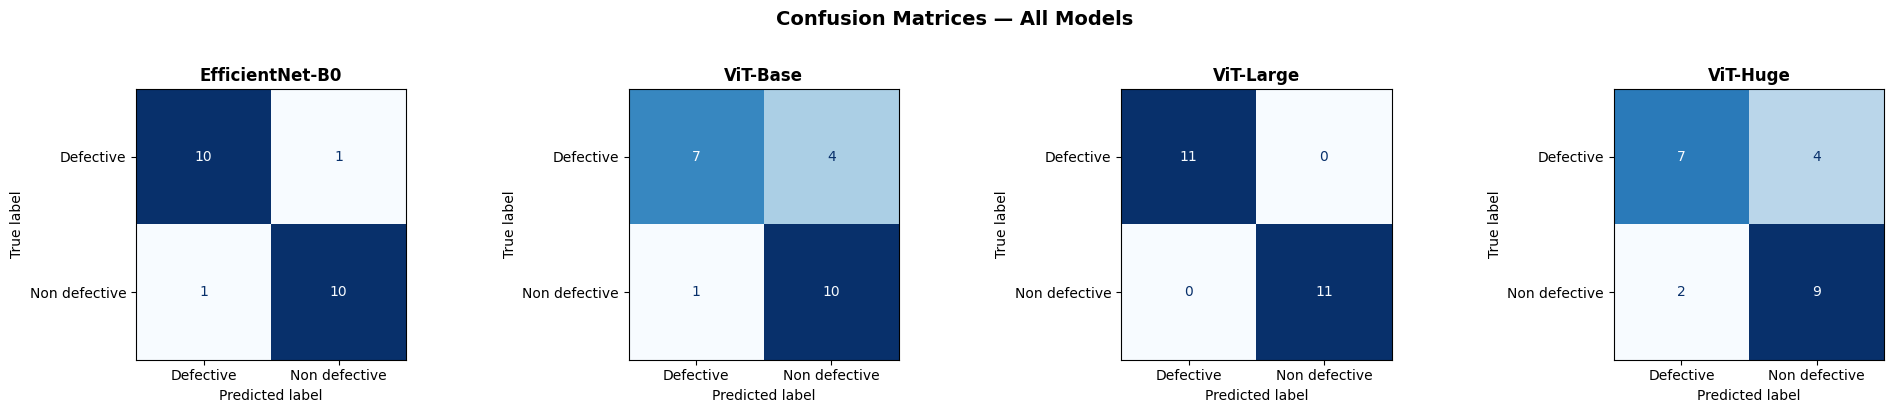

In [37]:
#Confusion Matrices

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
class_names = train_dataset.classes

for ax, (title, labels, preds) in zip(axes, [
    ('EfficientNet-B0', labels_cnn, preds_cnn),
    ('ViT-Base', labels_vb, preds_vb),
    ('ViT-Large', labels_vl, preds_vl),
    ('ViT-Huge', labels_vh, preds_vh),
]):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


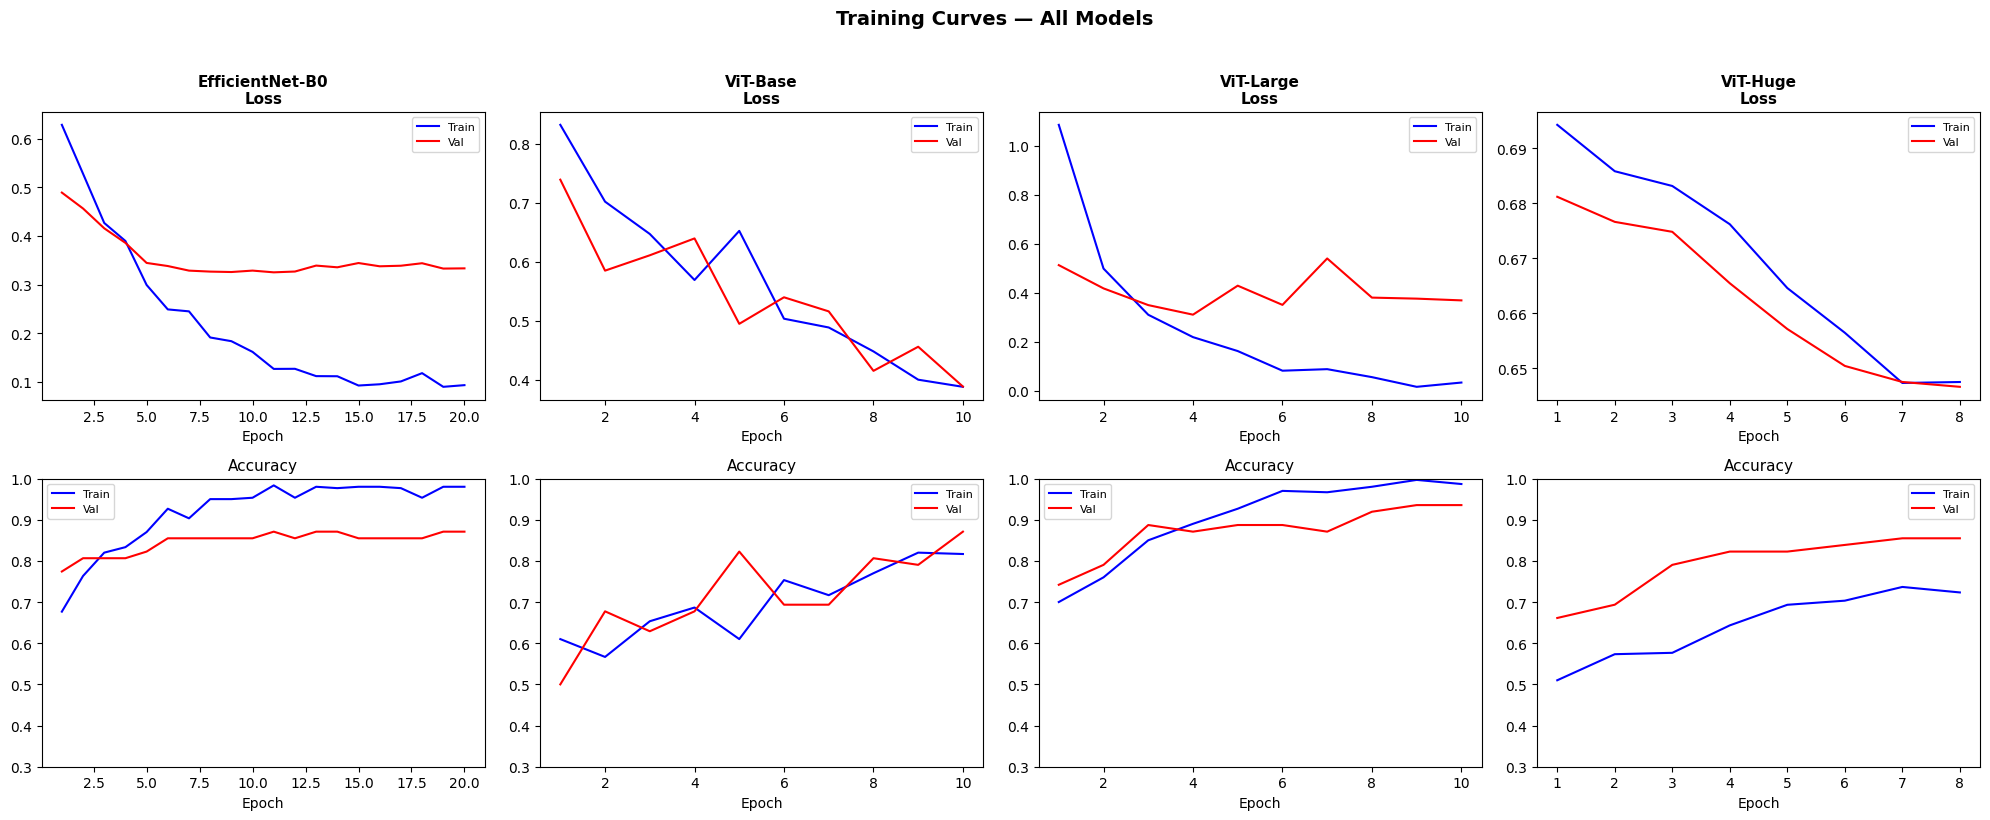

In [38]:
#Training Curves

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

histories = [
    ('EfficientNet-B0', history_cnn),
    ('ViT-Base', history_vit_base),
    ('ViT-Large', history_vit_large),
    ('ViT-Huge', history_vit_huge),
]

for col, (name, h) in enumerate(histories):
    epochs = range(1, len(h['train_loss']) + 1)

    # Loss
    axes[0, col].plot(epochs, h['train_loss'], 'b-', label='Train')
    axes[0, col].plot(epochs, h['val_loss'], 'r-', label='Val')
    axes[0, col].set_title(f'{name}\nLoss', fontsize=11, fontweight='bold')
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_xlabel('Epoch')

    # Accuracy
    axes[1, col].plot(epochs, h['train_acc'], 'b-', label='Train')
    axes[1, col].plot(epochs, h['val_acc'], 'r-', label='Val')
    axes[1, col].set_title(f'Accuracy', fontsize=11)
    axes[1, col].legend(fontsize=8)
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylim(0.3, 1.0)

plt.suptitle('Training Curves — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


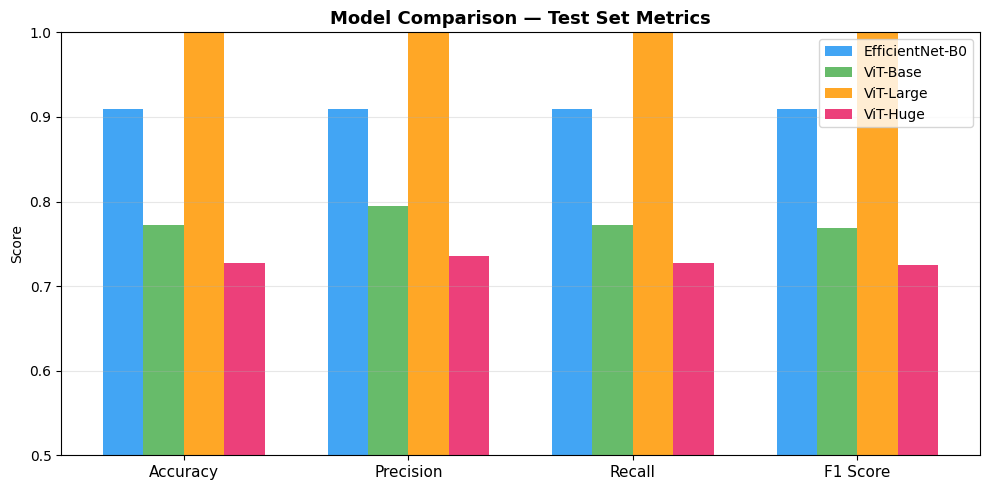

In [39]:
#Bar Chart Comparison

metrics_names = ['accuracy', 'precision', 'recall', 'f1']
model_names = ['EfficientNet-B0', 'ViT-Base', 'ViT-Large', 'ViT-Huge']
all_metrics = [metrics_cnn, metrics_vit_base, metrics_vit_large, metrics_vit_huge]

x = np.arange(len(metrics_names))
width = 0.18
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, m, color) in enumerate(zip(model_names, all_metrics, colors)):
    vals = [m[k] for k in metrics_names]
    ax.bar(x + i * width, vals, width, label=name, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1 Score'], fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Metrics', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Key Findings

1. *ViT-Large achieves the best performance, reaching 100% test accuracy.*
After fixing an optimizer bug from earlier experiments (where ViT-Large accidentally reused ViT-Base's optimizer and flatlined at ~47% training accuracy), ViT-Large emerged as the top performer. It trained smoothly, reaching 93.5% validation accuracy and perfect classification on the 22-image test set. This suggests that with proper optimization, a well-sized ViT can leverage its pretrained representations effectively even on small datasets.


2. *EfficientNet-B0 (CNN) is a strong and reliable second place at 90.9% accuracy.*
The CNN benefits from inductive biases (local receptive fields, translation equivariance) that make it data-efficient. It learned quickly and showed balanced precision and recall across both classes, making it a dependable choice for small-scale image classification.


3. *Bigger ViT ≠ better — ViT-Huge underperforms despite staged fine-tuning.*
With 632M parameters, ViT-Huge was the weakest model at 72.7% accuracy. Even with a two-stage training strategy (head-only → partial fine-tuning of the last 2 blocks), the model could not adapt enough. The vast majority of its parameters remained frozen, and the small dataset was insufficient to meaningfully update even the unfrozen layers. ViT-Base (86M params) also underperformed at 77.3%, sitting in an awkward middle ground where full fine-tuning on 300 images leads to noisy optimization.


4. *Proper training setup matters more than model size.*
The most dramatic result change came not from switching architectures but from fixing a bug. ViT-Large went from 68% (broken optimizer) to 100% (correct optimizer) — a reminder that implementation details like optimizer state, learning rate schedules, and fresh parameter groups can have a larger impact than architectural choices.


5. *Data augmentation provides consistent improvements.*
Using the same augmentation pipeline (flips, rotation, color jitter) across all models improved results compared to earlier runs, particularly for EfficientNet-B0 which jumped from 86% to 91%.


**Model Size and Data Scale**
The results reveal a non-linear relationship between model size and performance on small datasets. ViT-Large (304M params) outperformed both the smaller ViT-Base (86M) and the larger ViT-Huge (632M). This suggests a "sweet spot" — ViT-Large's pretrained features are rich enough to transfer well with full fine-tuning, while ViT-Huge is too large to adapt with limited data, even with partial unfreezing. CNNs like EfficientNet-B0 remain competitive due to their architectural priors, but a properly tuned transformer can match or exceed them.


**Limitations**

- **Very small test set** (22 images): ViT-Large's perfect score could shift by 1–2 images on a re-run due to training stochasticity. Results should be interpreted as trends rather than precise rankings.
- **Binary classification only**: a more granular defect taxonomy might yield different relative performance across architectures.
- **No extensive hyperparameter search:** each model used reasonable but not optimized settings. ViT-Huge in particular might benefit from more aggressive unfreezing or longer training.
- **Single dataset**: findings may not generalize to other small-scale vision tasks with different image characteristics.
